## Introduction
The background of news recommendation in news APP is **required us to predict the user's future click behavior based on the data information of the user's historical browsing and clicking on news articles, that is, the news article that the user clicked for the last time**.

## Data Overview
User interaction data, including 300,000 users, nearly 3 million clicks, and more than 360,000 different news articles. At the same time, each news article has a corresponding embedding vector representation.

From it, 200,000 users' click log data are extracted as the training set, 50,000 users' click log data are used as the test set A, and 50,000 users' click log data are used as the test set B.

# Data table

- train_click_log.csv: training set user click log
- testA_click_log.csv: test set user click log
- articles.csv: news article information data table
- articles_emb.csv: news article embedding vector representation


| **Field** | **Description** |
| :---------------------: | :------------------------------: |
| user_id | User id |
| click_article_id | Click article id |
| click_timestamp | Click timestamp |
| click_environment | Click environment |
| click_deviceGroup | Click device group |
| click_os | Click operating system |
| click_country | Click city |
| click_region | Click region |
| click_referrer_type | Click source type |
| article_id | Article id, corresponding to click_article_id |
| category_id | Article type id |
| created_at_ts | Article creation timestamp |
| words_count | Article word count |
| emb_1,emb_2,...,emb_249 | Article embedding vector representation |

## Evaluation method understanding
The format we finally submitted is for each user, We will give the recommendation results of five articles, sorted from the beginning to the end according to the click probability.

The article that each user clicked last will only have one real answer, so we will see whether there is a real answer among the five articles we recommend.

For example, for user1, our submission will be:
>user1, article1, article2, article3, article4, article5.

The formula of the evaluation index is as follows:
$$
score(user) = \sum_{k=1}^5 \frac{s(user, k)}{k}
$$

If article1 is the real user clicked article, that is, article1 hits, then s(user1,1)=1, s(user1,2-4) are all 0, if article2 is the article clicked by the user, then s(user,2)=1/2, s(user,1,3,4,5) are all 0. That is, score(user)=the inverse of the hit number. If none of them hit, then score(user1)=0. This is reasonable, because we hope that the hit result is as close as possible to the front, and the score is just high at this time.

## Project Understanding
According to the project introduction, we must first clarify the goal of our project: predict the news article that the user clicked last time based on the data information of the user's historical browsing and clicking on the news. From this goal, we will find that this project is different from the ordinary structured projects we have encountered before. There are two main points:

- First of all, in terms of the goal, we want to predict the news article that was clicked last, that is, we recommend news articles to users, not like the previous problem of predicting a number or predicting which type of data

- In terms of data, through the given data, we will find that this kind of data is not the kind of feature + label data we encountered before, but based on real business scenarios, the user's click log

So when we get this topic, our thinking direction is to combine our goals and **turn the prediction problem into a supervised learning problem (feature + label), and then we can perform ML, DL and other modeling predictions**.

Then we should naturally have the following questions in our minds:

- How to turn it into a supervised learning problem?
- What kind of supervised learning problem does it turn into?
- What features can we use?
- What models can we try?
- What strategies do we have for recommending tens of thousands of articles this time?

Of course, these questions will not be answered immediately after we see the project, but as long as there is a problem, we can find a way to solve it. For example, what kind of supervised learning problem does the second question above turn into?

Since we are predicting the news article that the user clicked on last, if we predict a certain article from 360,000 articles, we may first think that this may be a multi-classification problem (select 1 from 360,000 categories), but such a huge classification problem may be difficult for us to do, so can we convert it?

Since we want to predict the article that was clicked last, if we can predict the probability that a user will click on a certain article for the last time, does it indirectly solve this problem? Isn’t the article with the highest probability the news article that the user may click on last time? This turns the original problem into a click-through rate prediction problem (user, article) --> click probability (soft classification), and this problem is the classification problem in the supervised learning field that we are familiar with. In this way, when we build models later, we basically have a general direction for the choice of model, such as the simplest logistic regression model.

In this way, we should have a general solution to the solution of this project. We should first turn it into a classification problem. The classification label is whether the user will click on a certain article. The characteristics of the classification problem will include users and articles. We need to train a classification model to predict the probability of a user clicking on a certain article for the last time. Then there will be several questions: How to turn it into a supervised learning problem? How to make training sets and test sets? What features can we use? What models can we try? Faced with 360,000 articles and recommendations from more than 200,000 users, what strategies do we have to reduce the scale of the problem? How to make the final prediction?

## Multi-way recall

The so-called "multi-way recall" strategy refers to using different strategies, features or simple models to recall a part of the candidate set respectively, and then mix the candidate sets together for use by the subsequent sorting model. It can be clearly seen that the "multi-way recall strategy" is the result of a trade-off between "computation speed" and "recall rate". Among them, various simple strategies ensure the rapid recall of candidate sets, and strategies designed from different angles ensure that the recall rate is close to the ideal state, so as not to damage the sorting effect. The following figure is a schematic diagram of multi-way recall. In multi-way recall, each strategy is completely unrelated, so it can generally be written in concurrent multi-threads at the same time, which can be more efficient.






In [ ]:
!pip install -q tensorflow==2.8.0
!pip install -q faiss-gpu
!pip install -q deepctr
!pip install -q deepmatch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 497.6/497.6 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.5/462.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.3/781.3 kB 17.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-gbq 0.23.2 requires google-auth-oauthlib>=0.7.0, but you have google-auth-oauthlib 0.4.6 which is incompatible.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.8.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5

---

1. **aiss-cpu (Faiss):**
- Features: Faiss is a library for efficient similarity search and dense vector clustering. It provides a range of fast similarity search algorithms, especially for large-scale nearest neighbor search tasks.
- Advantages: In a CPU environment, Faiss provides efficient vector similarity search and clustering algorithms that can be used to process large-scale data sets. Its algorithm design and implementation enable it to quickly process high-dimensional vectors, such as in image similarity search, natural language processing, and recommendation systems.
2. **deepctr:**
- Features: DeepCTR is a Python library for click-through rate (CTR) prediction using deep learning models. It provides a variety of deep learning models for building recommendation systems, advertising click prediction models, and other CTR-related tasks.
- Advantages: DeepCTR provides a rich set of deep learning models, allowing users to flexibly choose models suitable for their data and tasks for CTR prediction. It also provides model evaluation and comparison tools to help users better understand and optimize model performance.
3. **deepmatch:**
- Features: DeepMatch is a Python library for recommendation systems and matching tasks, using deep learning methods. It provides a variety of pre-built deep learning models specifically for recommendation-related tasks such as item recommendation and user-item matching.
- Advantages: DeepMatch provides an easy-to-use interface and a rich selection of models, allowing users to quickly build and train personalized recommendation systems. It also provides data preprocessing tools and recommendation algorithm evaluation tools to help users better understand and optimize the performance of recommendation models.

In [ ]:
# Data processing and analysis related libraries
import pandas as pd # Used for data processing and analysis, providing powerful data structures and data analysis tools.
import numpy as np # Used for scientific computing, supporting multidimensional arrays and matrix operations, etc.

# Progress bar and data structure related libraries
from tqdm import tqdm # Used to display a progress bar, which is convenient for observing progress when processing large amounts of data.
from collections import defaultdict # You can create a dictionary with default values. When you access a non-existent key, it will be automatically created and assigned a default value.
import collections # Provides additional data structures and collection types, such as counters, ordered dictionaries, etc.

# Operating system interaction and mathematical operation related libraries
import os # Used to interact with the operating system, such as file operations, path processing, etc.
import math # Provides mathematical operation functions, such as trigonometric functions, logarithmic functions, etc.

# Warning control and serialization related libraries
import warnings
warnings.filterwarnings('ignore') # Used to control the display of warning information, all warnings are ignored here.
import pickle # Used to serialize and deserialize Python objects, which can be saved to or read from files.

# Similarity search and clustering related libraries
import faiss # Used for efficient similarity search and clustering algorithms.

# Random number generation and feature scaling related libraries
import random # Used to generate pseudo-random numbers.
from sklearn.preprocessing import MinMaxScaler # Used for feature scaling, scaling feature values ​​to a specific range.

# Date and time processing related libraries
from datetime import datetime # Used to process dates and times, including date creation, formatting, and time calculation.

# Deep learning related libraries
from deepctr.feature_column import SparseFeat, VarLenSparseFeat # From the DeepCTR library, used to define sparse features and variable-length sparse features.
from tensorflow.python.keras import backend as K # Keras from TensorFlow, providing underlying operation functions for building and training deep learning models.
from tensorflow.python.keras.models import Model # Used to build neural network models, define the structure and training process of the model.
from tensorflow.keras.preprocessing.sequence import pad_sequences # Used for sequence padding to make sequences of different lengths have the same length.
from deepmatch.models import * # Import all models in the DeepMatch library for tasks such as recommendation systems.
from deepmatch.utils import sampledsoftmaxloss # From the DeepMatch library, used for custom loss functions suitable for specific deep learning tasks.

# Other libraries
import logging # Used for logging, convenient for debugging and tracking program running status.
import time # Provides time-related functions, such as getting the current time, timing, etc.
import lightgbm as lgb # Lightweight gradient boosting framework for machine learning tasks.
from gensim.models import Word2Vec # From the Gensim library, used to train word vector models.

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.8.0


In [ ]:
from google.colab import drive

# 连接到Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = '/content/drive/My Drive/项目/推荐系统/data/data_raw/' # 数据路径，用于指定原始数据的存储位置
save_path = '/content/drive/My Drive/项目/推荐系统/data/temp_results/' # 存储路径，用于指定临时结果的保存位置

# 做召回评估的一个标志, 如果不进行评估就是直接使用全量数据进行召回
metric_recall = False

## Reading data
In general rs projects, the data reading part is mainly divided into three modes, and different modes correspond to different data sets:
1. debug mode: The purpose of this mode is to help us build a simple baseline based on the data and run it through, to ensure that there are no problems with the baseline code written. Since the data of recommendation projects is often very large, if all the data is directly used for analysis and to build a baseline framework, it will often cause time and equipment loss. **So at this time, we often need to randomly extract a part of the samples from the training set of massive data for debugging (train_click_log_sample)**, and run a baseline first.
2. Offline verification mode: The purpose of this mode is to help us select the appropriate model and some hyperparameters offline based on the existing training set data. **So we only need to load the entire training set (train_click_log)**, and then divide the entire training set into a training set and a validation set. The training set is the training data of the model, and the validation set helps us adjust the parameters of the model and some other hyperparameters.
3. Online mode: We use debug mode to build a baseline for a recommendation system project, and use offline verification mode to select the model and some hyperparameters. This part is to actually predict the given test set and submit it online. **So the training data set used in this part is the full data set (train_click_log+test_click_log)**

Next, we will first establish different generation import functions for these three different data reading modes, so that we can import data in different modes later.

In [ ]:
# debug模式： 从训练集中划出一部分数据来调试代码
def get_all_click_sample(data_path, sample_nums=1000):
    """
        训练集中采样一部分数据调试
        data_path: 原数据的存储路径
        sample_nums: 采样数目（这里由于机器的内存限制，可以采样用户做）
    """
    all_click = pd.read_csv(data_path + 'train_click_log.csv')
    all_user_ids = all_click.user_id.unique()

    sample_user_ids = np.random.choice(all_user_ids, size=sample_nums, replace=False)
    all_click = all_click[all_click['user_id'].isin(sample_user_ids)]

    all_click = all_click.drop_duplicates((['user_id', 'click_article_id', 'click_timestamp']))
    return all_click

# 读取点击数据，这里分成线上和线下，如果是为了获取线上提交结果应该讲测试集中的点击数据合并到总的数据中
# 如果是为了线下验证模型的有效性或者特征的有效性，可以只使用训练集
def get_all_click_df(data_path, offline=True):
    if offline:
        all_click = pd.read_csv(data_path + 'train_click_log.csv')
    else:
        trn_click = pd.read_csv(data_path + 'train_click_log.csv')
        tst_click = pd.read_csv(data_path + 'testA_click_log.csv')

        all_click = pd.concat([trn_click,tst_click])

    all_click = all_click.drop_duplicates((['user_id', 'click_article_id', 'click_timestamp']))
    return all_click

In [ ]:
# 读取文章的基本属性
def get_item_info_df(data_path):
    item_info_df = pd.read_csv(data_path + 'articles.csv')

    # 为了方便与训练集中的click_article_id拼接，需要把article_id修改成click_article_id
    item_info_df = item_info_df.rename(columns={'article_id': 'click_article_id'})

    return item_info_df

In [ ]:
# 读取文章的Embedding数据
# 读取包含文章嵌入（Embedding）数据的 CSV 文件，并将其转换为嵌入字典（embedding dictionary）
def get_item_emb_dict(data_path):
    item_emb_df = pd.read_csv(data_path + 'articles_emb.csv')

    item_emb_cols = [x for x in item_emb_df.columns if 'emb' in x]
    item_emb_np = np.ascontiguousarray(item_emb_df[item_emb_cols])
    # 进行归一化
    item_emb_np = item_emb_np / np.linalg.norm(item_emb_np, axis=1, keepdims=True)

    item_emb_dict = dict(zip(item_emb_df['article_id'], item_emb_np))
    pickle.dump(item_emb_dict, open(save_path + 'item_content_emb.pkl', 'wb'))

    return item_emb_dict


# 1. `item_emb_cols = [x for x in item_emb_df.columns if 'emb' in x]`：从 DataFrame 的列中筛选出包含 `'emb'` 的列名，并存储在列表 `item_emb_cols` 中。
# 2. `item_emb_np = np.ascontiguousarray(item_emb_df[item_emb_cols])`：将 DataFrame 中包含嵌入数据的列转换为 NumPy 数组，并存储在 `item_emb_np` 中。
# 3. `item_emb_np = item_emb_np / np.linalg.norm(item_emb_np, axis=1, keepdims=True)`：对嵌入数组进行归一化，确保每个嵌入向量的范数（norm）为1。这样做可以使得嵌入向量更具有可比性。
# 4. `item_emb_dict = dict(zip(item_emb_df['article_id'], item_emb_np))`：将文章ID和归一化后的嵌入向量一一对应，并将其存储在字典 `item_emb_dict` 中。
# 5. `pickle.dump(item_emb_dict, open(save_path + 'item_content_emb.pkl', 'wb'))`：使用 pickle 序列化将嵌入字典保存到文件中


In [ ]:
# 采样数据
all_click_df = get_all_click_sample(data_path)


max_min_scaler = lambda x : (x-np.min(x))/(np.max(x)-np.min(x))

# 全量训练集
# all_click_df = get_all_click_df(data_path = data_path, offline=False)

# 对时间戳进行归一化,用于在关联规则的时候计算权重
all_click_df['click_timestamp'] = all_click_df[['click_timestamp']].apply(max_min_scaler)

In [ ]:
item_info_df = get_item_info_df(data_path)

In [ ]:
item_emb_dict = get_item_emb_dict(data_path)

## Utility Functions

### Get user-article-time function
This will be used in user collaborative filtering based on association rules

In [ ]:
# 根据点击时间获取用户的点击文章序列   {user1: [(item1, time1), (item2, time2)..]...}
def get_user_item_time(click_df):

    click_df = click_df.sort_values('click_timestamp')

    def make_item_time_pair(df):
        return list(zip(df['click_article_id'], df['click_timestamp']))

    user_item_time_df = click_df.groupby('user_id')[['click_article_id', 'click_timestamp']].apply(lambda x: make_item_time_pair(x))\
                                                            .reset_index().rename(columns={0: 'item_time_list'})
    user_item_time_dict = dict(zip(user_item_time_df['user_id'], user_item_time_df['item_time_list']))

    return user_item_time_dict

### Get article-user-time function
This is used when collaborative filtering articles based on association rules

In [ ]:
# Get the user sequence of the product clicked based on time {item1: [(user1, time1), (user2, time2)...]...}
def get_item_user_time_dict(click_df):
    """
    获取每个物品被哪些用户点击过的字典，键为物品ID，值为用户点击该物品的列表
    :param click_df: 包含用户点击信息的数据表
    :return: 物品ID到用户点击列表的字典
    """
    def make_user_time_pair(df):
        return list(zip(df['user_id'], df['click_timestamp']))

    click_df = click_df.sort_values('click_timestamp')
    item_user_time_df = click_df.groupby('click_article_id')[['user_id', 'click_timestamp']].apply(lambda x: make_user_time_pair(x))\
                                                            .reset_index().rename(columns={0: 'user_time_list'})

    item_user_time_dict = dict(zip(item_user_time_df['click_article_id'], item_user_time_df['user_time_list']))
    return item_user_time_dict

### Get history and last click
This will be used when evaluating recall results, feature engineering, and making labels into supervised learning test sets

In [ ]:
# Get the historical clicks and last click of the current data
def get_hist_and_last_click(all_click):

    all_click = all_click.sort_values(by=['user_id', 'click_timestamp'])
    click_last_df = all_click.groupby('user_id').tail(1)

    # If the user has only one click record (len(user_df) == 1), the hist_func function will return all click records of the user.
    # Otherwise, the hist_func function will return all click records except the last click.
    def hist_func(user_df):
        if len(user_df) == 1:
            return user_df
        else:
            return user_df[:-1]

    click_hist_df = all_click.groupby('user_id').apply(hist_func).reset_index(drop=True)

    return click_hist_df, click_last_df



# 1. `click_last_df = all_click.groupby('user_id').tail(1)`: Group the sorted data by user ID and get the last click data of each user.
# 2. `def hist_func(user_df):`: Defines an internal function `hist_func`, which accepts a user data DataFrame and returns the user's historical click data based on the user's click history.
# 3. `if len(user_df) == 1:`: Checks whether the number of clicks in the user data is 1. If so, returns the user data itself, because there is only one click and the historical click sequence cannot be constructed.
# 4. `return user_df[:-1]`: If the number of user clicks is greater than 1, returns all click data except the last click to construct the user's historical click sequence.
# 5. `click_hist_df = all_click.groupby('user_id').apply(hist_func).reset_index(drop=True)`: Group all click data by user ID,
# and apply the `hist_func` function to each user to get the historical click data of each user. Then reindex the result and store it in `click_hist_df`.

### Get article attribute characteristics

In [ ]:
# Get the basic attributes corresponding to the article id and save them in the form of a dictionary for easy recall in the later stage. It can be used directly in the cold start stage.
def get_item_info_dict(item_info_df):
    max_min_scaler = lambda x : (x-np.min(x))/(np.max(x)-np.min(x))
    item_info_df['created_at_ts'] = item_info_df[['created_at_ts']].apply(max_min_scaler)

    item_type_dict = dict(zip(item_info_df['click_article_id'], item_info_df['category_id']))
    item_words_dict = dict(zip(item_info_df['click_article_id'], item_info_df['words_count']))
    item_created_time_dict = dict(zip(item_info_df['click_article_id'], item_info_df['created_at_ts']))

    return item_type_dict, item_words_dict, item_created_time_dict

### Get the article information that the user has clicked on in history

In [ ]:
def get_user_hist_item_info_dict(all_click):
    # This function is used to obtain various information about the user's historical clicks, and returns the following dictionaries respectively:
    # 1. A collection dictionary of the categories of articles that the user has historically clicked
    # 2. A collection dictionary of the IDs of articles that the user has historically clicked
    # 3. A dictionary of the average number of words in articles that the user has historically clicked
    # 4. A dictionary of the creation time (normalized) of the article that the user last clicked
    # Get a collection dictionary of the categories of articles that the user has historically clicked corresponding to user_id
    user_hist_item_typs = all_click.groupby('user_id')['category_id'].agg(set).reset_index()
    user_hist_item_typs_dict = dict(zip(user_hist_item_typs['user_id'], user_hist_item_typs['category_id']))
    # 1. Group by user_id and aggregate the categories (category_id) of articles clicked by users into a collection
    # 2. Convert the result into a dictionary, with the key being user_id and the value being the category collection

    # Get the collection dictionary of articles clicked by users corresponding to user_id
    user_hist_item_ids_dict = all_click.groupby('user_id')['click_article_id'].agg(set).reset_index()
    user_hist_item_ids_dict = dict(zip(user_hist_item_ids_dict['user_id'], user_hist_item_ids_dict['click_article_id']))
    # 1. Group by user_id and aggregate the article IDs (click_article_id) clicked by the user as a set
    # 2. Convert the result into a dictionary, with the key being user_id and the value being the article ID set

    # Get the average word count of the articles that the user corresponding to user_id has clicked on in history
    user_hist_item_words = all_click.groupby('user_id')['words_count'].agg('mean').reset_index()
    user_hist_item_words_dict = dict(zip(user_hist_item_words['user_id'], user_hist_item_words['words_count']))
    # 1. Group by user_id and calculate the average number of words (words_count) of articles clicked by users
    # 2. Convert the result into a dictionary with the key being user_id and the value being the average number of words

    # Get the creation time of the article that the user corresponding to user_id last clicked
    all_click_ = all_click.sort_values('click_timestamp')
    user_last_item_created_time = all_click_.groupby('user_id')['created_at_ts'].apply(lambda x: x.iloc[-1]).reset_index()
    # 1. Sort the data by click time (click_timestamp)
    # 2. Group by user_id and extract the creation time (created_at_ts) of the article that each user clicked for the last time

    max_min_scaler = lambda x : (x - np.min(x)) / (np.max(x) - np.min(x))
    user_last_item_created_time['created_at_ts'] = user_last_item_created_time[['created_at_ts']].apply(max_min_scaler)
    # 1. Define a normalization function to normalize the data to between 0 and 1
    # 2. Normalize the extracted creation time data

    user_last_item_created_time_dict = dict(zip(user_last_item_created_time['user_id'], \
                                                user_last_item_created_time['created_at_ts']))
    # Convert the result to a dictionary, with the key being user_id and the value being the normalized creation time

    return user_hist_item_typs_dict, user_hist_item_ids_dict, user_hist_item_words_dict, user_last_item_created_time_dict
    # Returns four dictionaries, including the article category set, article ID set, average word count, and the normalized creation time of the last clicked article by the user.

1. **Get the category set of articles that users have clicked on in history**: By counting the categories of articles that each user has clicked on and saving them in the form of a set, we can understand the user's interest preferences, so that the category information of the article can be considered when recommending, improving the accuracy and personalization of the recommendation.
2. **Get the ID set of articles that users have clicked on in history**: Record the ID set of articles that each user has clicked on, which can be used to build the user's historical behavior sequence and then perform sequence modeling, such as using a sequence model or a sequence recommendation algorithm to predict the articles that the user may be interested in in the future.
3. **Get the average number of words in articles that users have clicked on in history**: Calculate the average number of words in articles that each user has clicked on, which can be used as a feature of user behavior to help the recommendation system better understand the user's behavior habits and preferences.
4. **Get the creation time of the article that the user last clicked on**: Record the creation time of the article that each user last clicked on, which can be used for time-based recommendation strategies, such as the most recent click is more likely to reflect the user's current interests.

### Get the topk articles with the most clicks

In [ ]:
# Get the most recently clicked articles
def get_item_topk_click(click_df, k):
    topk_click = click_df['click_article_id'].value_counts().index[:k]
    return topk_click

## Define a multi-way recall dictionary

In [ ]:
# Get the attribute information of the article and save it in the form of a dictionary for easy query
item_type_dict, item_words_dict, item_created_time_dict = get_item_info_dict(item_info_df)

In [ ]:
# Define a dictionary for multi-channel recall and save the results of each channel recall in this dictionary
user_multi_recall_dict =  {'itemcf_sim_itemcf_recall': {},
                           'embedding_sim_item_recall': {},
                           'cold_start_recall': {}}

1. `'itemcf_sim_itemcf_recall': {}`: indicates the recall result based on item collaborative filtering. The value corresponding to this key is an empty dictionary, which is used to store the recall result obtained based on the item collaborative filtering algorithm.
2. `'embedding_sim_item_recall': {}`: indicates the recall result based on Embedding similarity. The value corresponding to this key is an empty dictionary, which is used to store the recall result obtained based on the Embedding similarity algorithm.
3. `'cold_start_recall': {}`: indicates the cold start recall result. The value corresponding to this key is an empty dictionary, which is used to store the recall result obtained by the cold start algorithm.

In [ ]:
# Extract the last click as the recall estimate
trn_hist_click_df, trn_last_click_df = get_hist_and_last_click(all_click_df)

## Recall effect evaluation function
After the recall is completed, sometimes you need to adjust the current recall method or parameters to achieve a better recall effect, because the recall result determines the upper limit of the final sorting. The following will also provide a recall evaluation method

In [ ]:
def metrics_recall(user_recall_items_dict, trn_last_click_df, topk=50):
    # This function evaluates the hit rate of the first 10, 20, 30, 40, 50 articles in the recall

    # Convert the user's last click record into a dictionary, with the key being user_id and the value being click_article_id
    last_click_item_dict = dict(zip(trn_last_click_df['user_id'], trn_last_click_df['click_article_id']))

    # Get the number of users in the recall dictionary
    user_num = len(user_recall_items_dict)

    # Evaluate the hit rate of the first 10, 20, 30, 40, 50 articles in the recall
    for k in range(10, topk + 1, 10):
        hit_num = 0  # Record the number of hits

        # Traverse each user and their recalled article list
        for user, item_list in user_recall_items_dict.items():
            # Get the top k recalled results (article ID)
            tmp_recall_items = [x[0] for x in user_recall_items_dict[user][:k]]

            # If the user's last clicked article is among the top k results recalled, it is counted as a hit
            if last_click_item_dict[user] in set(tmp_recall_items):
                hit_num += 1

        # Calculate the hit rate, hit rate = hit times / total number of users
        hit_rate = round(hit_num * 1.0 / user_num, 5)

        # Print result
        print('topk:', k, ' | hit_num:', hit_num, ' | hit_rate:', hit_rate, ' | user_num:', user_num)

## Calculate similarity matrix

This part mainly obtains the similarity matrix through collaborative filtering and vector retrieval. The similarity matrix is ​​mainly divided into user2user and item2item. The following obtains the similarity matrix of item2item based on itemcf in turn.
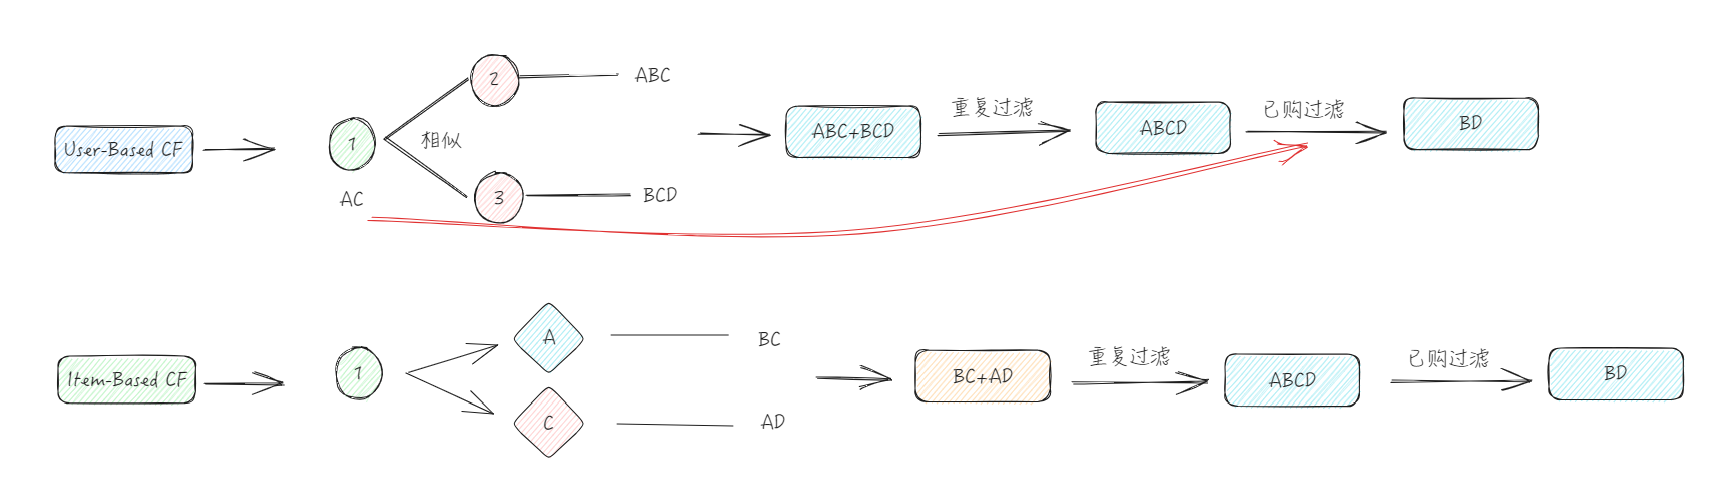

### itemcf i2i_sim

When calculating the item2item similarity matrix, association rules are used so that the similarity of the calculated articles also takes into account:

1. The time weight of user clicks
2. The order weight of user clicks
3. The time weight of article creation

In [ ]:
user_item_time_dict = get_user_item_time(all_click_df)

In [ ]:
def itemcf_sim(all_click_df, option='raw'):


    # Calculate item similarity
    # Use two nested loops to traverse each user's clicked article list and calculate the similarity between two items.
    # For each pair of items i and j, calculate their similarity sim(i,j). Commonly used similarity calculation methods include cosine similarity, etc.


    user_item_time_dict = get_user_item_time(all_click_df)

    # Initialize dictionary
    i2i_sim = defaultdict(dict)
    item_cnt = defaultdict(int)


    if option == 'raw':
        print('原始相似度计算\n')
    # Original similarity accumulation process
    # Traverse each user and the list of items and time they clicked
        for user, item_time_list in tqdm(user_item_time_dict.items(), desc="Building item-item similarity matrix (raw)"):
            # Traverse each item i clicked by the user
            for i, i_click_time in item_time_list:
                item_cnt[i] += 1  # Record the number of times item i is clicked

                # Perform nested traversal on item i and item j clicked by each user
                for j, j_click_time in item_time_list:
                    if i == j:  # If item i and item j are the same item, skip
                        continue

                    i2i_sim[i].setdefault(j, 0)  # Initialize the similarity between item i and item j to 0 (if not initialized yet)

                    # Calculate the similarity between item i and item j, and accumulate the similarity
                    i2i_sim[i][j] += 1 / math.log(len(item_time_list) + 1)


    elif option == 'weighted':
        print('加权相似度计算\n')
        # Weighted similarity accumulation process
        for user, item_time_list in tqdm(user_item_time_dict.items(), desc="Building item-item similarity matrix (weighted)"):
            for loc1, (i, i_click_time) in enumerate(item_time_list):
                item_cnt[i] += 1
                i2i_sim.setdefault(i, {})
                for loc2, (j, j_click_time) in enumerate(item_time_list):
                    if i == j:
                        continue

                    # Consider the forward and reverse order clicks of the article
                    loc_alpha = 1.0 if loc2 > loc1 else 0.7
                    # Location information weight, the parameters can be adjusted
                    loc_weight = loc_alpha * (0.9 ** (np.abs(loc2 - loc1) - 1))
                    # Click on the time weight, the parameters can be adjusted
                    click_time_weight = np.exp(0.7 ** np.abs(i_click_time - j_click_time))
                    # The weight of the creation time of the two articles, the parameters of which can be adjusted
                    created_time_weight = np.exp(0.8 ** np.abs(item_created_time_dict[i] - item_created_time_dict[j]))
                    # The greater the difference in word count between two articles, the lower the similarity
                    words_weight = np.exp(0.7 ** np.abs(item_words_dict[i] - item_words_dict[j]))
                    i2i_sim[i].setdefault(j, 0)
                    # Consider the weights of multiple factors to calculate the final similarity between articles
                    i2i_sim[i][j] += loc_weight * click_time_weight * created_time_weight * words_weight/ math.log(len(item_time_list) + 1)

    # Similarity normalization process
    i2i_sim_final = defaultdict(dict)
    for i, related_items in i2i_sim.items():
        for j, wij in related_items.items():
            i2i_sim_final[i][j] = wij / math.sqrt(item_cnt[i] * item_cnt[j])

    # Save the similarity matrix locally
    with open(save_path + 'itemcf_i2i_sim.pkl', 'wb') as f:
        pickle.dump(i2i_sim_final, f)

    return i2i_sim_final

#### About similarity calculation

1. **Similarity accumulation process**:

   $$
   \text{sim}(i, j) = \sum_{u \in U_{ij}} \frac{1}{\log(1 + |N(u)|)}
   $$

  Among them:
  - $ \text{sim}(i, j) $ represents the similarity between item $ i $ and item $ j $.
  - $ U_{ij} $ represents the set of items $ i $ and $ j $ that have been clicked by the user at the same time.
  - $ N(u) $ represents the number of items clicked by user $ u $.

2. **Similarity normalization process**:

   $$
   \text{sim_normalized}(i, j) = \frac{\text{sim}(i, j)}{\sqrt{c(i) \times c(j)}}
   $$

  Among them:
  - $ \text{sim_normalized}(i, j) $ represents the normalized similarity between item $ i $ and item $ j $.
  - $ c(i) $ and $ c(j) $ represent the total number of clicks on item $ i $ and $ j $, respectively.


> `i2i_sim[i][j] += 1 / math.log(len(item_time_list) + 1) ` Why is it calculated this way?

Similarity is calculated by the number of co-occurrences. Here, 1 / log(len(item_time_list) + 1) is used as the increase in similarity, so that the length of the click list of different users can be standardized.

- Number of co-clicks: The similarity value reflects the frequency of co-occurrence of two items in the click record of the same user. The more clicks, the higher the similarity value.
- Normalization: `1 / math.log(len(item_time_list) + 1)` is the normalization of the number of clicks, which can reduce the impact of long click lists on similarity calculations.

Assume the following user click data:

- **User A**: Clicked items 1, 2, 3
- **User B**: Clicked items 1, 2
- **User C**: Clicked items 2, 3

Steps to calculate similarity:
1. **Item 1 and Item 2**:
- User A and User B both clicked on Item 1 and Item 2, so the similarity between Item 1 and Item 2 in the similarity matrix increases.
- User A clicked on Item 1 and Item 2 (2 times), and User B also clicked on it (1 time), so `i2i_sim[1][2]` increases by `1 / log(3)` (assuming that the length of User A's click list is 3).
2. **Item 1 and Item 3**:
- User A clicked on Item 1 and Item 3 (1 time), and User C clicked on Item 3 (1 time), so the similarity between Item 1 and Item 3 in the similarity matrix increases by `1 / log(3)` (assuming that the length of User A's click list is 3).
3. **Item 2 and Item 3**:
- User A and User C clicked on Item 2 and Item 3, so the similarity between Item 2 and Item 3 in the similarity matrix will increase by `1 / log(3)` (assuming the length of user A's click list is 3).


- `loc_alpha = 1.0 if loc2 > loc1 else 0.7`: This line of code calculates the weight of the position information, that is, considering the order in which users click on articles. If article j is clicked after article i, loc_alpha is 1.0, otherwise it is 0.7. This is done to emphasize that users are more likely to be interested in the last clicked article rather than the previously clicked articles.
- `loc_weight = loc_alpha * (0.9 ** (np.abs(loc2 - loc1) - 1))`: This line of code calculates the weight based on the position information. The position weight depends on the click order between articles, and the farther the distance, the smaller the weight. The parameter 0.9 is the decay coefficient of the position weight, which is used to reduce the influence of articles with farther distance on similarity.
- `click_time_weight = np.exp(0.7 ** np.abs(i_click_time - j_click_time))`: This line of code calculates the weight of the click time. The click time weight considers the time interval between users clicking on two articles. The shorter the time interval, the larger the weight, which means that the user is more likely to have similar interests in the two articles.
- `created_time_weight = np.exp(0.8 ** np.abs(item_created_time_dict[i] - item_created_time_dict[j]))`: This line of code calculates the weight of the article creation time. The article creation time weight takes into account the difference in creation time between the two articles. If the creation time of the two articles is similar, the weight is larger, otherwise it is smaller.
- `i2i_sim[i][j] += loc_weight * click_time_weight * created_time_weight / math.log(len(item_time_list) + 1)`: Finally, the similarity between article i and article j is calculated, taking into account the location information, click time, and the weight of the article creation time. The similarity calculation here is in the form of a weighted sum, in which the weights mentioned above are used, and divided by a logarithm to balance the impact of frequent clicks.

In [ ]:
i2i_sim = itemcf_sim(all_click_df, option='weighted')

加权相似度计算



Building item-item similarity matrix (weighted): 100%|██████████| 1000/1000 [00:00<00:00, 1725.95it/s]


### usercf u2u_sim

When calculating the similarity between users, some simple association rules can also be used, such as user activity weight. Here, the number of user clicks is used as an indicator of user activity.

In [ ]:
def get_user_activate_degree_dict(all_click_df):
    all_click_df_ = all_click_df.groupby('user_id')['click_article_id'].count().reset_index()

    # Normalize user activity
    mm = MinMaxScaler()
    all_click_df_['click_article_id'] = mm.fit_transform(all_click_df_[['click_article_id']])
    user_activate_degree_dict = dict(zip(all_click_df_['user_id'], all_click_df_['click_article_id']))
    # Here, user activity is measured by counting the number of articles clicked by users. After normalization, a value in the range of [0, 1] can be obtained, indicating the relative activity of the user.
    return user_activate_degree_dict

In [ ]:
def usercf_sim(all_click_df, user_activate_degree_dict):
    """
    User similarity matrix calculation
    :param all_click_df: data table
    :param user_activate_degree_dict: user activity degree dictionary
    return user similarity matrix
    """

    # Get a dictionary of which users have clicked on each item, with the key being the item ID and the value being a list of users who clicked on the item
    item_user_time_dict = get_item_user_time_dict(all_click_df)

    # Initialize user similarity matrix
    u2u_sim = {}
    # A dictionary that counts the number of items clicked by each user
    user_cnt = defaultdict(int)

    # Iterate through each item and the list of users who clicked it
    for item, user_time_list in tqdm(item_user_time_dict.items()):
        # Iterate through each user and their click time
        for u, click_time in user_time_list:
            # Count the number of items clicked by each user
            user_cnt[u] += 1
            # Initialize the user similarity matrix, or create an empty dictionary if it does not exist
            u2u_sim.setdefault(u, {})
            # Traverse each user and their click time (second traversal, used to calculate user similarity)
            for v, click_time in user_time_list:
                # Initialize the user similarity matrix and create an entry with a value of 0 if it does not exist
                u2u_sim[u].setdefault(v, 0)
                # If two users are the same, skip (do not calculate the similarity between yourself and yourself)
                if u == v:
                    continue
                # Calculate the weight of user similarity, taking into account the user's activity
                activate_weight = 100 * 0.5 * (user_activate_degree_dict[u] + user_activate_degree_dict[v])
                # user_activate_degree_dict[u] and user_activate_degree_dict[v] are the activity levels of users u and v (i.e. the normalized number of items they clicked).
                # Update the similarity value of the corresponding user in the user similarity matrix
                u2u_sim[u][v] += activate_weight / math.log(len(user_time_list) + 1)

    # Copy the user similarity matrix to prevent modification of the original data
    u2u_sim_ = u2u_sim.copy()
    # Normalize the similarity values ​​in the user similarity matrix
    for u, related_users in u2u_sim.items():
        for v, wij in related_users.items():
            u2u_sim_[u][v] = wij / math.sqrt(user_cnt[u] * user_cnt[v])

    # Save the obtained user similarity matrix locally
    pickle.dump(u2u_sim_, open(save_path + 'usercf_u2u_sim.pkl', 'wb'))

    return u2u_sim_


In [ ]:
# 由于usercf计算时候太耗费内存了，这里就不直接运行了
# 如果是采样的话，是可以运行的
user_activate_degree_dict = get_user_activate_degree_dict(all_click_df)
u2u_sim = usercf_sim(all_click_df, user_activate_degree_dict)

100%|██████████| 1780/1780 [00:00<00:00, 20437.73it/s]


### item embedding sim

The use of Embedding to calculate the similarity between items is to obtain articles that do not appear in the click data during the subsequent cold start. There is a special introduction to cold start later. Here I will briefly talk about faiss.

faiss is a set of software libraries for clustering or similarity search open sourced by Facebook's AI team. The underlying layer is implemented in C++. Faiss is widely used in recommendation-related businesses because of its super superior performance.

The faiss toolkit is generally used in the vector recall part of the recommendation system. When doing vector recall, it is either u2u, u2i or i2i, where u and i refer to user and item. We know that in actual scenarios, the number of users and items is huge. The most easily thought of recall based on vector similarity is to use two layers of loops to traverse the user list or item list to calculate the similarity of two vectors, but this is impractical in the face of massive data. Faiss is used to accelerate the calculation of the topk index vectors that are most similar to a query vector.

---

Faiss is an open-source software library developed by Facebook's AI research team for efficient similarity search and clustering of dense vectors. It is particularly useful in scenarios where large-scale similarity search is required, such as recommendation systems, image retrieval, and natural language processing tasks. Faiss is implemented in C++ with bindings available for Python and other languages.

The key feature of Faiss is its ability to perform approximate nearest neighbor search (ANN), which significantly speeds up the search process while maintaining high-quality results. Faiss achieves this by employing advanced algorithms and data structures optimized for high-dimensional vector spaces.

Example:
Let's consider a recommendation system scenario where we have a large number of user and item embeddings (dense vectors) representing users' preferences and items' features. The goal is to find the top-k most similar items to a given query item for personalized recommendations.


```python
import faiss

# Sample data: embeddings of items (item_vectors) and the query item (query_vector)
item_vectors = [[0.1, 0.2, 0.3], [0.4, 0.5, 0.6], [0.7, 0.8, 0.9], ...]
query_vector = [0.3, 0.4, 0.5]

# Convert the data to a numpy array
item_vectors = np.array(item_vectors, dtype=np.float32)
query_vector = np.array(query_vector, dtype=np.float32)

# Create an index for searching in Faiss (FlatL2 index, which uses L2 distance)
index = faiss.IndexFlatL2(item_vectors.shape[1])

# Add the item embeddings to the index
index.add(item_vectors)

# Perform the similarity search with the query vector
k = 5  # Number of nearest neighbors to retrieve
D, I = index.search(np.array([query_vector]), k)

# D: Distance of the query vector to the nearest neighbors (L2 distances)
# I: Indices of the k nearest neighbors in the item_vectors

# Print the results
print("Top 5 similar items to the query item:")
for i in I[0]:
    print(item_vectors[i])
```

**Faiss query principle:**

Index structure construction: In Faiss, the vector data set to be searched must first be constructed into an index structure. Faiss provides a variety of index structures, such as flat index, inverted file index (IVF), product quantization index (PQ), etc. Each index structure has its applicable scenarios and characteristics, and the appropriate index structure can be selected according to actual needs.

Vector encoding: Before building the index structure, it is usually necessary to encode the vector data. The purpose of encoding is to map high-dimensional vectors to low-dimensional space to reduce the amount of calculation and storage space. Common encoding methods include vector quantization, hash encoding, etc.

Query process: Once the index structure is built, it can be queried. The query process is usually achieved by calculating the similarity between the vector to be queried and the vector stored in the index structure. Faiss provides a variety of query methods, such as exact search, approximate search, etc. In approximate search, Faiss uses some approximate algorithms to speed up the search process, such as product quantization, locality sensitive hashing, etc.

Result return: After the query is completed, Faiss will return the index or distance of several vectors that are most similar to the query vector. Users can choose the number of results to be returned as needed, and perform subsequent processing and analysis on the returned results.

1. **Product Quantization (PQ)**:
- In product quantization, a high-dimensional vector is decomposed into multiple sub-vectors, and each sub-vector is independently vectorized. This can map the original high-dimensional vector to a low-dimensional subspace, thereby reducing the amount of calculation and storage space.
- The key to product quantization is how to decompose the original vector into sub-vectors and design a suitable quantization method. Common product quantization methods include Product Quantization, Residual Product Quantization, etc.
- Product quantization can significantly reduce the search time while maintaining the search quality, and is particularly suitable for approximate nearest neighbor search of large-scale high-dimensional data.
2. **Locality Sensitive Hashing (LSH)**:
- Locality sensitive hashing is an approximate nearest neighbor search method based on hash functions. The core idea is to map similar vectors into the same bucket so that similar vectors can be quickly located when querying.
- LSH uses multiple hash functions to hash vectors and generate multiple hash values. Then, the vectors are mapped into buckets based on these hash values. When querying, you only need to search for similar vectors in the bucket of the query vector and its adjacent buckets without traversing the entire data set.
- LSH has high search efficiency and scalability when processing large-scale data, and is especially suitable for approximate nearest neighbor search of high-dimensional data. a

faiss uses PCA and PQ (Product quantization) for vector compression and encoding. Of course, other technologies are used for optimization, but PCA and PQ are the core parts.




Calculate the similarity matrix between articles based on the article embedding. ,

- Establish a mapping between article index and article id; ,
- Unitize the article embedding vector;
- Establish a faiss index and perform similarity query;
- Save the similarity matrix.

In [ ]:
import numpy as np
import faiss
import collections
import pickle
from tqdm import tqdm

def embdding_sim(click_df, item_emb_df, save_path, topk):
    """
        Calculate the article embedding similarity matrix based on content
        :param click_df: data table
        :param item_emb_df: article embedding
        :param save_path: save path
        :patam topk: find the topk most similar articles
        return article similarity matrix

        Idea: For each article, return the topk most similar articles based on embedding similarity, but because there are too many articles, faiss is used here to speed up
    """

    # Dictionary mapping between article index and article id
    item_idx_2_rawid_dict = dict(zip(item_emb_df.index, item_emb_df['article_id']))

    item_emb_cols = [x for x in item_emb_df.columns if 'emb' in x]
    item_emb_np = np.ascontiguousarray(item_emb_df[item_emb_cols].values, dtype=np.float32)
    # Normalize vector
    item_emb_np = item_emb_np / np.linalg.norm(item_emb_np, axis=1, keepdims=True)

    # Create a faiss index
    item_index = faiss.IndexFlatIP(item_emb_np.shape[1])   # Create a faiss index, IndexFlatIP represents the inner product index, and the parameter is the dimension of the embedding vector.
    item_index.add(item_emb_np)
    index.search(item_emb_np, topk) # The returned list

    # Save the result of vector search as the corresponding relationship of the original id
    item_sim_dict = collections.defaultdict(dict)

    # Adding a progress bar using tqdm
    for target_idx, sim_value_list, rele_idx_list in tqdm(zip(range(len(item_emb_np)), sim, idx), total=len(item_emb_np)):
        target_raw_id = item_idx_2_rawid_dict[target_idx]
        # Starting from 1 is to remove the product itself, so the final similar products are only topk-1
        for rele_idx, sim_value in zip(rele_idx_list[1:], sim_value_list[1:]):
            rele_raw_id = item_idx_2_rawi
    # Perform a similarity query on the embedding vector of each article in the index and return the similarity (sim) and index value (idx) of the topk most similar vectors for each vector.
    sim, idx = item_d_dict[rele_idx]
            item_sim_dict[target_raw_id][rele_raw_id] = item_sim_dict.get(target_raw_id, {}).get(rele_raw_id, 0) + sim_value

    # Save i2i similarity matrix
    pickle.dump(item_sim_dict, open(save_path + 'emb_i2i_sim.pkl', 'wb')) # Save the article similarity matrix as a pickle file.
    return item_sim_dict

In [ ]:
item_emb_df = pd.read_csv(data_path + '/articles_emb.csv')
# emb_i2i_sim = embdding_sim(all_click_df, item_emb_df, save_path, topk=10)

### itemcf recall

The article similarity matrix has been obtained through collaborative filtering and Embedding retrieval. The idea of ​​collaborative filtering is used below to recall articles similar to the user's historical articles.
When recalling here, the association rule method is also used:
1. Consider the weight of the order of similar articles and historical clicked articles (see the code for details)
2. Consider the weight of the article creation time, that is, consider the weight of the difference in creation time between similar articles and historical clicked articles
3. Consider the weight of article content similarity (Use Embedding to calculate the similarity of similar articles, but it should be noted here that the similarity between all products is not calculated when Embedding, so there is no similarity between similar articles and historical clicked articles, which requires special processing)

In [ ]:
# Recall i2i based on article interaction and content
def content_based_recommend(user_id, user_item_time_dict, i2i_sim, sim_item_topk, recall_item_num, item_topk_click, item_created_time_dict, emb_i2i_sim):
    """
        Recall based on collaborative filtering of articles
        :param user_id: user id
        :param user_item_time_dict: dictionary, get the user's clicked article sequence according to the click time {user1: [(item1, time1), (item2, time2)..]...}
        :param i2i_sim: dictionary, article similarity matrix
        :param sim_item_topk: integer, select the top k articles most similar to the current article
        :param recall_item_num: integer, the last number of recalled articles
        :param item_topk_click: list, list of articles with the most clicks, user recall completion
        :param emb_i2i_sim: dictionary based on content embedding calculation of article similarity matrix

        return: recalled article list [(item1, score1), (item2, score2)...]
    """
    # Get articles with user historical interactions
    user_hist_items = user_item_time_dict[user_id]
    user_hist_items_ = {user_id for user_id, _ in user_hist_items}

    item_rank = {}
    for loc, (i, click_time) in enumerate(user_hist_items):
        for j, wij in sorted(i2i_sim[i].items(), key=lambda x: x[1], reverse=True)[:sim_item_topk]:
            if j in user_hist_items_:
                continue

            # Article creation time difference weight
            created_time_weight = np.exp(0.8 ** np.abs(item_created_time_dict[i] - item_created_time_dict[j]))
            # The position weight of the historical article in the sequence of similar articles and historical clicked articles
            loc_weight = (0.9 ** (len(user_hist_items) - loc))

            content_weight = 1.0
            if emb_i2i_sim.get(i, {}).get(j, None) is not None:
                content_weight += emb_i2i_sim[i][j]
            if emb_i2i_sim.get(j, {}).get(i, None) is not None:
                content_weight += emb_i2i_sim[j][i]

            item_rank.setdefault(j, 0)
            item_rank[j] += created_time_weight * loc_weight * content_weight * wij

    # Less than 10, use popular products to complete
    if len(item_rank) < recall_item_num:
        for i, item in enumerate(item_topk_click):
            if item in item_rank.items(): # The filled item should not be in the original list
                continue
            item_rank[item] = - i - 100
            if len(item_rank) == recall_item_num:
                break

    item_rank = sorted(item_rank.items(), key=lambda x: x[1], reverse=True)[:recall_item_num]

    return item_rank

```python
content_weight = 1.0
if emb_i2i_sim.get(i, {}).get(j, None) is not None:
    content_weight += emb_i2i_sim[i][j]
if emb_i2i_sim.get(j, {}).get(i, None) is not None:
    content_weight += emb_i2i_sim[j][i]

```

Here, emb_i2i_sim is the article similarity matrix calculated based on content embedding. Since the similarity between all articles is not calculated during embedding calculation, when considering the content similarity weights of article i and article j, content_weight is initialized to 1.0.
Then check whether there is similarity between article i and article j and similarity between article j and article i in emb_i2i_sim. If so, add the corresponding similarity value to content_weight.
In this way, when there is no directly calculated similarity between two articles, content_weight remains at 1.0; if there is an indirect similarity relationship (that is, either article i has similarity to article j, or article j has similarity to article i), the value of content_weight will be increased accordingly, which makes up for the deficiency of not directly calculating the similarity between all articles to a certain extent and realizes special processing.

#### itemcf sim recall

In [ ]:
# First, itemcf is recalled. For recall evaluation, the last click is extracted.

if metric_recall:
    trn_hist_click_df, trn_last_click_df = get_hist_and_last_click(all_click_df)
else:
    trn_hist_click_df = all_click_df

user_recall_items_dict = collections.defaultdict(dict)
user_item_time_dict = get_user_item_time(trn_hist_click_df)

i2i_sim = pickle.load(open(save_path + 'itemcf_i2i_sim.pkl', 'rb'))
emb_i2i_sim = pickle.load(open(save_path + 'emb_i2i_sim.pkl', 'rb'))

sim_item_topk = 20
recall_item_num = 10
item_topk_click = get_item_topk_click(trn_hist_click_df, k=50)

np.random.seed(42)
for user in tqdm(trn_hist_click_df['user_id'].sample(500).unique()):
    user_recall_items_dict[user] = content_based_recommend(user, user_item_time_dict, \
                                                        i2i_sim, sim_item_topk, recall_item_num, \
                                                        item_topk_click, item_created_time_dict, emb_i2i_sim)

user_multi_recall_dict['itemcf_sim_itemcf_recall'] = user_recall_items_dict
pickle.dump(user_multi_recall_dict['itemcf_sim_itemcf_recall'], open(save_path + 'itemcf_recall_dict.pkl', 'wb'))

if metric_recall:
    # Recall effectiveness evaluation
    metrics_recall(user_multi_recall_dict['itemcf_sim_itemcf_recall'], trn_last_click_df, topk=recall_item_num)

100%|██████████| 362/362 [00:00<00:00, 966.47it/s]


#### embedding sim recall

In [ ]:
# Here is for recall evaluation, so extract the last click
if metric_recall:
    trn_hist_click_df, trn_last_click_df = get_hist_and_last_click(all_click_df)
else:
    trn_hist_click_df = all_click_df

user_recall_items_dict = collections.defaultdict(dict)
user_item_time_dict = get_user_item_time(trn_hist_click_df)
i2i_sim = pickle.load(open(save_path + 'emb_i2i_sim.pkl','rb'))

sim_item_topk = 20
recall_item_num = 10

item_topk_click = get_item_topk_click(trn_hist_click_df, k=50)

np.random.seed(42)
for user in tqdm(trn_hist_click_df['user_id'].sample(500).unique()):
    user_recall_items_dict[user] = content_based_recommend(user, user_item_time_dict, i2i_sim, sim_item_topk,
                                                        recall_item_num, item_topk_click, item_created_time_dict, emb_i2i_sim)

user_multi_recall_dict['embedding_sim_item_recall'] = user_recall_items_dict
pickle.dump(user_multi_recall_dict['embedding_sim_item_recall'], open(save_path + 'embedding_sim_item_recall.pkl', 'wb'))

if metric_recall:
    metrics_recall(user_multi_recall_dict['embedding_sim_item_recall'], trn_last_click_df, topk=recall_item_num)

100%|██████████| 362/362 [00:00<00:00, 1905.33it/s]


### usercf recall

Based on user collaborative filtering, the core idea is to recommend articles with similar historical clicks to users. Since this involves historical articles of similar users, some association rules can still be added to weight the articles that users may click. The association rules used here mainly consider the relationship weights between historical clicks of similar users and historical clicks of recommended users. The relationship here can directly refer to the similar approach of collaborative filtering based on items, except that this is a cumulative process of the relationship between recommended items. The following are some relationship weights used and related codes:

1. Calculate the similarity between the recommended user's historical clicked articles and the historical clicked articles of similar users, the time difference between article creation, and the sum of relative positions as their respective weights

In [ ]:
# User-based recall u2u2i
def user_based_recommend(user_id, user_item_time_dict, u2u_sim, sim_user_topk, recall_item_num,
                         item_topk_click, item_created_time_dict, emb_i2i_sim):
    """
        Recall based on collaborative filtering of articles
        :param user_id: user id
        :param user_item_time_dict: dictionary, get the user's clicked article sequence according to the click time {user1: [(item1, time1), (item2, time2)..]...}
        :param u2u_sim: dictionary, article similarity matrix
        :param sim_user_topk: integer, select the top k users most similar to the current user
        :param recall_item_num: integer, the last number of recalled articles
        :param item_topk_click: list, list of articles with the most clicks, user recall completion
        :param item_created_time_dict: list of article creation time
        :param emb_i2i_sim: dictionary based on content embedding calculation of article similarity matrix

        return: recalled article list [(item1, score1), (item2, score2)...]
    """
    # Historical interaction
    user_item_time_list = user_item_time_dict[user_id]    #  [(item1, time1), (item2, time2)..]
    user_hist_items = set([i for i, t in user_item_time_list])   # There are multiple interactions between a user and an article. Here we need to deduplicate

    items_rank = {}
    for sim_u, wuv in sorted(u2u_sim[user_id].items(), key=lambda x: x[1], reverse=True)[:sim_user_topk]:
        for i, click_time in user_item_time_dict[sim_u]:
            if i in user_hist_items:
                continue
            items_rank.setdefault(i, 0)

            loc_weight = 1.0
            content_weight = 1.0
            created_time_weight = 1.0

            # The current article interacts with the historical articles that the user has read.
            for loc, (j, click_time) in enumerate(user_item_time_list):
                # Relative position weight when clicking
                loc_weight += 0.9 ** (len(user_item_time_list) - loc)
                # Content similarity weight
                if emb_i2i_sim.get(i, {}).get(j, None) is not None:
                    content_weight += emb_i2i_sim[i][j]
                if emb_i2i_sim.get(j, {}).get(i, None) is not None:
                    content_weight += emb_i2i_sim[j][i]

                # Create time difference weights
                created_time_weight += np.exp(0.8 * np.abs(item_created_time_dict[i] - item_created_time_dict[j]))

            items_rank[i] += loc_weight * content_weight * created_time_weight * wuv

    # item filled
    if len(items_rank) < recall_item_num:
        for i, item in enumerate(item_topk_click):
            if item in items_rank.items(): # The filled item should not be in the original list
                continue
            items_rank[item] = - i - 100
            if len(items_rank) == recall_item_num:
                break

    items_rank = sorted(items_rank.items(), key=lambda x: x[1], reverse=True)[:recall_item_num]

    return items_rank

#### usercf sim recall

In [ ]:
# This is for recall evaluation, so the last click is extracted
# Since the process of calculating the similarity between users in usercf consumes too much memory, the full data is not run here, but the data after a sampling is run
if metric_recall:
    trn_hist_click_df, trn_last_click_df = get_hist_and_last_click(all_click_df)
else:
    trn_hist_click_df = all_click_df

user_recall_items_dict = collections.defaultdict(dict)
user_item_time_dict = get_user_item_time(trn_hist_click_df)

u2u_sim = pickle.load(open(save_path + 'usercf_u2u_sim.pkl', 'rb'))

sim_user_topk = 20
recall_item_num = 10
item_topk_click = get_item_topk_click(trn_hist_click_df, k=50)


np.random.seed(42)
for user in tqdm(trn_hist_click_df['user_id'].sample(500).unique()):
    user_recall_items_dict[user] = user_based_recommend(user, user_item_time_dict, u2u_sim, sim_user_topk, \
                                                        recall_item_num, item_topk_click, item_created_time_dict, emb_i2i_sim)

pickle.dump(user_recall_items_dict, open(save_path + 'usercf_u2u2i_recall.pkl', 'wb'))

if metric_recall:
    metrics_recall(user_recall_items_dict, trn_last_click_df, topk=recall_item_num)

100%|██████████| 362/362 [00:04<00:00, 80.62it/s]


## 冷启动问题

**Cold start problems can be divided into three categories: article cold start, user cold start, and system cold start. **

- Article cold start: For a new article added to a platform system, there is no interaction record for the article. How to recommend it to users? (For our scenario, it can be considered that articles that have not appeared in the log data can be considered as cold start articles)
- User cold start: For a new user in a platform system, the user has no interaction information of the article. How to recommend it to the user? (For our scenario, it is whether the user in the test set has appeared in the log data corresponding to the test set. If not, then the user can be considered a cold start user. But sometimes it is not so strict. We can also set certain indicators to determine which users are cold start users, such as usage time, click-through rate, retention rate, etc.)
- System cold start: For a platform that has just been launched and there is no relevant historical data, it is a system cold start, which is actually a combination of the previous two.

**Analysis of cold start problem in current scenario:**

Analyzing the current data, we can find that there are only more than 30,000 articles that have been clicked in the log, while there are more than 300,000 articles in the entire article library. So will the last click of the user in the test set be on an article that does not appear in the log? If this happens, it means that there is no interactive information before the article clicked by the user, which is what we call article cold start. Through data analysis, we can also find that the proportion of data with only one click by the user in the test set is quite large. In fact, it is also difficult to recommend articles to users using models based on only one click of the user. In fact, the problem of user cold start can also be considered here, but here we only give some solutions and codes for item cold start, and some feasible practices for user cold start.

  1. Article Cold Start (Exploration Problem without Cold Start)
  
  In fact, we are not doing cold start for the sake of cold start, but guessing that users may click on some articles that do not appear in the log data. What we need to do is how to select some articles from nearly 270,000 articles as user cold start articles. This can actually be seen as a recall strategy. Here we use a simple and easy-to-understand rule-based recall strategy to obtain articles that users may click but do not appear in the log data.
  Now the question becomes: how to consider obtaining a small number of articles from 270,000 articles for each user? Randomly selecting some may be a solution. Here are some reference solutions.
    - Recall a part of articles similar to user history based on Embedding. Using the Embedding vector of the article, you can find articles that are similar to the articles that the user has clicked in history in the vector space.
    - Filter articles recalled based on Embedding by rules. For example, keep articles with the same theme and similar number of words as the articles that the user has clicked in history; select articles that are closer to the last click time of the test set user or articles on the same day. This can increase the possibility of the recalled articles being clicked by users.
  2. User cold start

  Here, we analyze the user click data in the test set and find that 20% of the users in the test set only click once. So can we make some strategic supplements for the recall of these users with very few clicks? Or can we add some articles directly based on the rules after sorting?

In [ ]:
# First, recall itemcf. No recall evaluation is needed here. This is just a strategy.
trn_hist_click_df = all_click_df

user_recall_items_dict = collections.defaultdict(dict)
user_item_time_dict = get_user_item_time(trn_hist_click_df)
i2i_sim = pickle.load(open(save_path + 'emb_i2i_sim.pkl','rb'))

sim_item_topk = 150
recall_item_num = 100 # Recall a little more articles to facilitate subsequent rule screening

np.random.seed(42)
item_topk_click = get_item_topk_click(trn_hist_click_df, k=50)
for user in tqdm(trn_hist_click_df['user_id'].sample(500).unique()):
    user_recall_items_dict[user] = content_based_recommend(user, user_item_time_dict, i2i_sim, sim_item_topk,
                                                        recall_item_num, item_topk_click,item_created_time_dict, emb_i2i_sim)
pickle.dump(user_recall_items_dict, open(save_path + 'cold_start_items_raw_dict.pkl', 'wb'))

100%|██████████| 362/362 [00:00<00:00, 839.15it/s]


In [ ]:
# Filter articles based on rules
# Keep articles with similar topics to those browsed by the user in history
# Keep articles with similar word count to those browsed by the user in history
# Keep articles with the last click on the day
# Return the final result based on similarity

def get_click_article_ids_set(all_click_df):
    return set(all_click_df.click_article_id.values)

def cold_start_items(user_recall_items_dict, user_hist_item_typs_dict, user_hist_item_words_dict, \
                     user_last_item_created_time_dict, item_type_dict, item_words_dict,
                     item_created_time_dict, click_article_ids_set, recall_item_num):
    """
        Recall some articles in the case of cold start
        :param user_recall_items_dict: Many articles recalled based on content embedding similarity, dictionary, {user1: [(item1, item2), ..], }
        :param user_hist_item_typs_dict: dictionary, topic mapping of articles clicked by users
        :param user_hist_item_words_dict: dictionary, word count mapping of historical articles clicked by users
        :param user_last_item_created_time_idct: dictionary, historical article creation time mapping clicked by users
        :param item_tpye_idct: dictionary, article topic mapping
        :param item_words_dict: dictionary, article word count mapping
        :param item_created_time_dict: dictionary, article creation time mapping
        :param click_article_ids_set: collection, articles clicked by users, that is, articles that appeared in the log
        :param recall_item_num: The number of recalled articles, which refers to the number of articles that did not appear in the log
    """

    cold_start_user_items_dict = {}
    for user, item_list in tqdm(user_recall_items_dict.items()):
        cold_start_user_items_dict.setdefault(user, [])
        for item, score in item_list:
            # Get historical article information
            hist_item_type_set = user_hist_item_typs_dict[user]
            hist_mean_words = user_hist_item_words_dict[user]
            hist_last_item_created_time = user_last_item_created_time_dict[user]
            hist_last_item_created_time = datetime.fromtimestamp(hist_last_item_created_time)

            # Get information about the currently recalled article
            curr_item_type = item_type_dict[item]
            curr_item_words = item_words_dict[item]
            curr_item_created_time = item_created_time_dict[item]
            curr_item_created_time = datetime.fromtimestamp(curr_item_created_time)

            # First, the article cannot appear in the user's historical clicks. Then filter according to the article topic, article word count, and article creation time.
            if curr_item_type not in hist_item_type_set or \
                item in click_article_ids_set or \
                abs(curr_item_words - hist_mean_words) > 200 or \
                abs((curr_item_created_time - hist_last_item_created_time).days) > 90:
                continue

            cold_start_user_items_dict[user].append((item, score))      # {user1: [(item1, score1), (item2, score2)..]...}

    # Need to control the number of cold start recalls
    cold_start_user_items_dict = {k: sorted(v, key=lambda x:x[1], reverse=True)[:recall_item_num] \
                                  for k, v in cold_start_user_items_dict.items()}

    pickle.dump(cold_start_user_items_dict, open(save_path + 'cold_start_user_items_dict.pkl', 'wb'))

    return cold_start_user_items_dict

The main purpose is to recall some articles that may be of interest to the user based on the user's historical browsing history and the characteristics of the article in the case of cold start. The specific logic is as follows:

Traverse the list of articles recalled based on embedding. For each article, obtain the relevant information of the user's historical clicked articles (theme set, average word count, last click time) and the information of the currently recalled article (theme, word count, creation time).

Filter according to a series of rules:

- The article cannot appear in the user's historical clicks to ensure the novelty of the recommendation.

- The article theme must be in the theme set of the user's historical clicked articles to ensure the theme similarity.

- The difference between the number of words in the article and the average number of words in the user's historical clicked articles cannot exceed 200 to ensure that the content length is similar.
- The difference between the creation time of the article and the creation time of the user's last click on the article cannot exceed 90 days to ensure that the recommended article is relatively new.

If the article passes these screening conditions, it will be added to the user's cold start recommendation list.

Finally, sort each user's cold start recommendation list according to the score of the article, and intercept the first recall_item_num articles to ensure that the number of recommendations meets the requirements.
Save the processed cold start recommendation results as a pickle file.


In [ ]:
all_click_df_ = all_click_df.copy()
all_click_df_ = all_click_df_.merge(item_info_df, how='left', on='click_article_id')
user_hist_item_typs_dict, user_hist_item_ids_dict, user_hist_item_words_dict, user_last_item_created_time_dict = get_user_hist_item_info_dict(all_click_df_)
click_article_ids_set = get_click_article_ids_set(all_click_df)
cold_start_user_items_dict = cold_start_items(user_recall_items_dict, user_hist_item_typs_dict, user_hist_item_words_dict, \
                                              user_last_item_created_time_dict, item_type_dict, item_words_dict, \
                                              item_created_time_dict, click_article_ids_set, recall_item_num)

user_multi_recall_dict['cold_start_recall'] = cold_start_user_items_dict

100%|██████████| 362/362 [00:00<00:00, 2257.18it/s]


## Multi-way recall merging
Multi-way recall merging is to merge the user article lists obtained by all previous recall strategies. The following is a summary of all previous recall results
1. Recall based on the similarity sim between items calculated by itemcf
2. Recall based on the similarity between items obtained by embedding search
5. Recall based on cold start strategy

In [ ]:
def combine_recall_results(user_multi_recall_dict, weight_dict=None, topk=25):
    final_recall_items_dict = {}

    # Each recall result is normalized according to the user, which is convenient for the subsequent multiple recall results. The weights of items of the same user are added together.
    def norm_user_recall_items_sim(sorted_item_list):
        # If there is no article or only one article in the cold start, return directly. The reason for this may be that the number of articles recalled in the cold start is too small.
        # There are no articles after rule-based filtering. You can also do some other strategic filtering here
        if len(sorted_item_list) < 2:
            return sorted_item_list

        min_sim = sorted_item_list[-1][1]
        max_sim = sorted_item_list[0][1]

        norm_sorted_item_list = []
        for item, score in sorted_item_list:
            if max_sim > 0:
                norm_score = 1.0 * (score - min_sim) / (max_sim - min_sim) if max_sim > min_sim else 1.0
            else:
                norm_score = 0.0
            norm_sorted_item_list.append((item, norm_score))

        return norm_sorted_item_list

    print('多路召回合并...')
    for method, user_recall_items in tqdm(user_multi_recall_dict.items()):
        print(method + '...')
        # When calculating the final recall result, you can also set a weight for each recall result.
        if weight_dict == None:
            recall_method_weight = 1
        else:
            recall_method_weight = weight_dict[method]

        for user_id, sorted_item_list in user_recall_items.items(): # Normalize
            user_recall_items[user_id] = norm_user_recall_items_sim(sorted_item_list)

        for user_id, sorted_item_list in user_recall_items.items():
            # print('user_id')
            final_recall_items_dict.setdefault(user_id, {})
            for item, score in sorted_item_list:
                final_recall_items_dict[user_id].setdefault(item, 0)
                final_recall_items_dict[user_id][item] += recall_method_weight * score

    final_recall_items_dict_rank = {}
    # The final recall quantity can also be controlled during multi-channel recall
    for user, recall_item_dict in final_recall_items_dict.items():
        final_recall_items_dict_rank[user] = sorted(recall_item_dict.items(), key=lambda x: x[1], reverse=True)[:topk]

    # Save the final result dictionary after multi-way recall to local
    pickle.dump(final_recall_items_dict_rank, open(os.path.join(save_path, 'final_recall_items_dict.pkl'),'wb'))

    return final_recall_items_dict_rank

In [ ]:
# Here, the weights of multiple recalls are given the same value. In fact, the parameter value can be adjusted according to the previous recall situation.
weight_dict = {'itemcf_sim_itemcf_recall': 1.0,
               'embedding_sim_item_recall': 1.0,
               'cold_start_recall': 1.0}

In [ ]:
# After the final merger, each user recalls 5 items for sorting
final_recall_items_dict_rank = combine_recall_results(user_multi_recall_dict, weight_dict, topk=150)

多路召回合并...


100%|██████████| 3/3 [00:00<00:00, 49.83it/s]

itemcf_sim_itemcf_recall...
embedding_sim_item_recall...
cold_start_recall...


In [ ]:
multi_recall_score_list = []

for user, items in tqdm(final_recall_items_dict_rank.items()):
    if isinstance(items, (list, tuple)):  # Make sure items is iterable
        for item, score in items:
            multi_recall_score_list.append([user, item, score])
    else:
        print(f"Error: items for user {user} is not iterable")

recall_df = pd.DataFrame(multi_recall_score_list, columns=['user_id', 'click_article_id', 'pred_score'])


100%|██████████| 362/362 [00:00<00:00, 637.11it/s]


In [ ]:
def submit(recall_df, topk=5, model_name=None):
    # Sort DataFrame based on 'user_id' and 'pred_score' columns
    recall_df = recall_df.sort_values(by=['user_id', 'pred_score'])

    # Add a 'rank' column to indicate the predicted rank of each user
    recall_df['rank'] = recall_df.groupby(['user_id'])['pred_score'].rank(ascending=False, method='first')

    # Check if each user has at least 'topk' posts
    tmp = recall_df.groupby('user_id').apply(lambda x: x['rank'].max())
    assert tmp.min() >= topk

    # Delete 'pred_score' column
    del recall_df['pred_score']

    # Select the top 'topk' predictions for each user and reshape the DataFrame
    submit = recall_df[recall_df['rank'] <= topk].set_index(['user_id', 'rank']).unstack(-1).reset_index()

    # Rename column names according to submission format
    submit.columns = [int(col) if isinstance(col, int) else col for col in submit.columns.droplevel(0)]
    submit = submit.rename(columns={'': 'user_id', 1: 'article_1', 2: 'article_2',
                                    3: 'article_3', 4: 'article_4', 5: 'article_5'})

    # Generate a file name to save the CSV file
    save_name = save_path + model_name + '_' + datetime.today().strftime('%m-%d') + '.csv'

    # Save the DataFrame as a CSV file without the index and including the header information
    submit.to_csv(save_name, index=False, header=True)

    return submit


In [ ]:
recall_df['click_article_id'] = recall_df['click_article_id'].astype(int)
# Generate submission file
submit(recall_df, topk=5, model_name='multiple_recall')

,user_id,article_1,article_2,article_3,article_4,article_5
0,804,244851,245077,245004,244936,243557
1,1139,30955,28747,245195,22024,245702
2,1630,206960,353849,203386,158772,149690
3,2228,289197,332517,332188,331070,328867
4,2871,332517,331583,332188,331070,328867
...,...,...,...,...,...,...
357,197976,286008,284464,285196,282249,279593
358,197980,30752,332517,31655,331583,30739
359,198115,284603,59069,237621,42223,235297
360,198372,161446,107196,162338,160132,160450
